# CS235 Fall 2024 Course Project

Student 1 -  Kyle Russell\
Student 2 -  Jimmy Wu\
Student 3 -  Jason Nguyen\
Student 4 -  Ahad Hassan\
Student 5 -  William Kirkpatrick

## Preliminary Questions

#### What data do you have?
The dataset we obtained was based on the Google form students from CS10C, CS105, and CS111 answered created from the many questions groups put on a Google sheet. Our group contributed four questions, which consisted of a Likert scale as well as 3 other questions that can be categorized as ordinal categorical data. The target variable for our project was the Likert scale, as it assessed on a scale of 1 to 5 how well a student learned in class. The three other questions that were asked to gather additional insight are as follows:
* Focus Duration: We asked about the average length of time a student could stay focused in class, with options ranging form 0 - 20 minutes to 80+ minutes.
* Social Distractions: We asked how often students got distracted by their phone or their friends during class, with answers going from Never to Always.
* External Distractions: We asked how often students found it difficult to pay attention during class due to outside factors, with answers matching our previous question.

#### What would you like to know?
How does the classroom environment impact students' ability to focus and lean?
* This question delves into how external distractions affects students perceptions of their focus and learning effectiveness in the classroom. Understanding these relationships offers insights on the topic of how students academic engagement and performance is impacted based on environmental factors. By examining the correlations between the diffrent levels of distractions, focus durations, and the learning outcomes our project is trying to identify specific elements of the classroom setting that could be improved to help aid students learning experiences for the better.

## Setup

In [6]:
# Import libraries
%matplotlib inline
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from scipy import stats

# Load data
df_full = pd.read_csv('CS105 F24 Mini-Project Survey (Responses) - Form Responses 1.csv')
df_full = df_full.rename(str.strip, axis='columns')

In [7]:
# Filter columns to relevent data
df = df_full[['How often do you feel unprepared for a class due to not understanding the material?',
       'How many hours of sleep do you get on average during college?',
       'On a scale of 1-5, how well do you learn in class?',
       'What would you consider the average length of time you can stay focused in class?',
       'How often do you go on your phone or talk to your friends during class?',
       'How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?']]

## Exploratory Data Analysis (EDA)

In [9]:
# Value Counts for all the questions we used
for col in df.columns:
    print('Value counts for:', df_full[col].value_counts())
    print("-"*40)  # Separator for each question

print('total rows:', df.shape[0])

Value counts for: How often do you feel unprepared for a class due to not understanding the material?
Often         125
Rarely         89
Very often     31
Never           4
Name: count, dtype: int64
----------------------------------------
Value counts for: How many hours of sleep do you get on average during college?
6 - 7 hours     92
5 - 6 hours     70
7 - 8 hours     48
4 - 5 hours     25
8 - 9 hours      9
0 - 3 hours      3
9 - 10 hours     2
Name: count, dtype: int64
----------------------------------------
Value counts for: On a scale of 1-5, how well do you learn in class?
3    125
4     71
2     37
1     10
5      6
Name: count, dtype: int64
----------------------------------------
Value counts for: What would you consider the average length of time you can stay focused in class?
20 - 40 mins    110
40 - 60 mins     90
0 - 20 mins      25
60 - 80 mins     20
80+ mins          4
Name: count, dtype: int64
----------------------------------------
Value counts for: How often do 

In [10]:
# Display the value counts (frequency) for each column
print('Mean of how well do you learn in class?:                 |', df['On a scale of 1-5, how well do you learn in class?'].mean())
print('Mode of how often student is unprepared due to material?:|', df['How often do you feel unprepared for a class due to not understanding the material?'].mode())
print('Mode of hours of sleep average during college?:          |', df['How many hours of sleep do you get on average during college?'].mode()[0])
print('Mode of how long can you stay focused in class?:         |', df['What would you consider the average length of time you can stay focused in class?'].mode()[0])
print('Mode for times on phone during class:                    |', df['How often do you go on your phone or talk to your friends during class?'].mode()[0])
print('Mode for how often found difficult to focus in class:    |', df['How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?'].mode()[0])

Mean of how well do you learn in class?:                 | 3.104417670682731
Mode of how often student is unprepared due to material?:| 0    Often
Name: How often do you feel unprepared for a class due to not understanding the material?, dtype: object
Mode of hours of sleep average during college?:          | 6 - 7 hours
Mode of how long can you stay focused in class?:         | 20 - 40 mins
Mode for times on phone during class:                    | Sometimes
Mode for how often found difficult to focus in class:    | Rarely


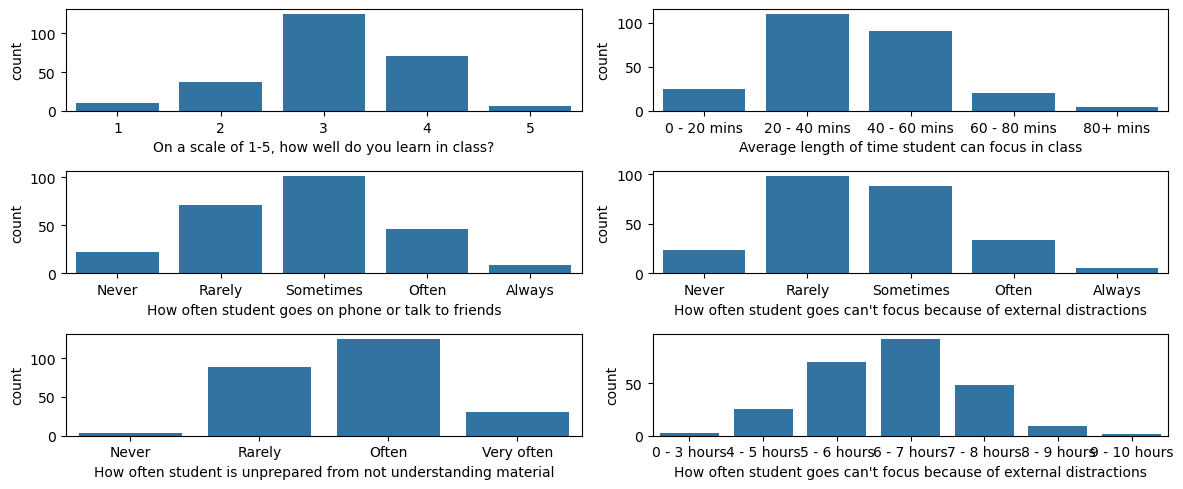

In [11]:
# Figure with 4 countplots (1 for each question)
fig, axes = plt.subplots(3, 2, figsize=(12, 5))

# Set the order for each of the columns (ordinal data)
learning_order = [1, 2, 3, 4, 5]  # 1 = "Poorly", 5 = "Excellently"
duration_order = ['0 - 20 mins', '20 - 40 mins', '40 - 60 mins', '60 - 80 mins', '80+ mins']
phone_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
distractions_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
prepared_order = ['Never', 'Rarely', 'Often', 'Very often']
sleep_order = ['0 - 3 hours', '4 - 5 hours', '5 - 6 hours', '6 - 7 hours', '7 - 8 hours', '8 - 9 hours', '9 - 10 hours'] 

# Create a count plot for each question
sns.countplot(x='On a scale of 1-5, how well do you learn in class?', data=df, ax=axes[0, 0], order=learning_order)

sns.countplot(x='What would you consider the average length of time you can stay focused in class?', data=df, ax=axes[0, 1], order=duration_order)
axes[0, 1].set_xlabel('Average length of time student can focus in class')

sns.countplot(x='How often do you go on your phone or talk to your friends during class?', data=df, ax=axes[1, 0], order=phone_order)
axes[1, 0].set_xlabel('How often student goes on phone or talk to friends')

sns.countplot(x='How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?', data=df, ax=axes[1, 1], order=distractions_order)
axes[1, 1].set_xlabel('How often student goes can\'t focus because of external distractions')

sns.countplot(x='How often do you feel unprepared for a class due to not understanding the material?', data=df, ax=axes[2, 0], order=prepared_order)
axes[2, 0].set_xlabel('How often student is unprepared from not understanding material')

sns.countplot(x='How many hours of sleep do you get on average during college?', data=df, ax=axes[2, 1], order=sleep_order)
axes[2, 1].set_xlabel('How often student goes can\'t focus because of external distractions')

# Display plots
plt.tight_layout()
plt.show()

# Data and Visualization

### Spider Plot
In this plot, I will compute the means for each ordinal categorical target in "How well do you learn in class?" (values 1 through 5) across the different factors of sleep, material preparedness, distractions, and focus length. I will display these means on a spider plot, which will be normalized to ensure an equal comparison across categories, helping to assess which factors contribute most to learning success. This approach helps identify key drivers of student learning without having to focus on specific values, providing insights into general trends.

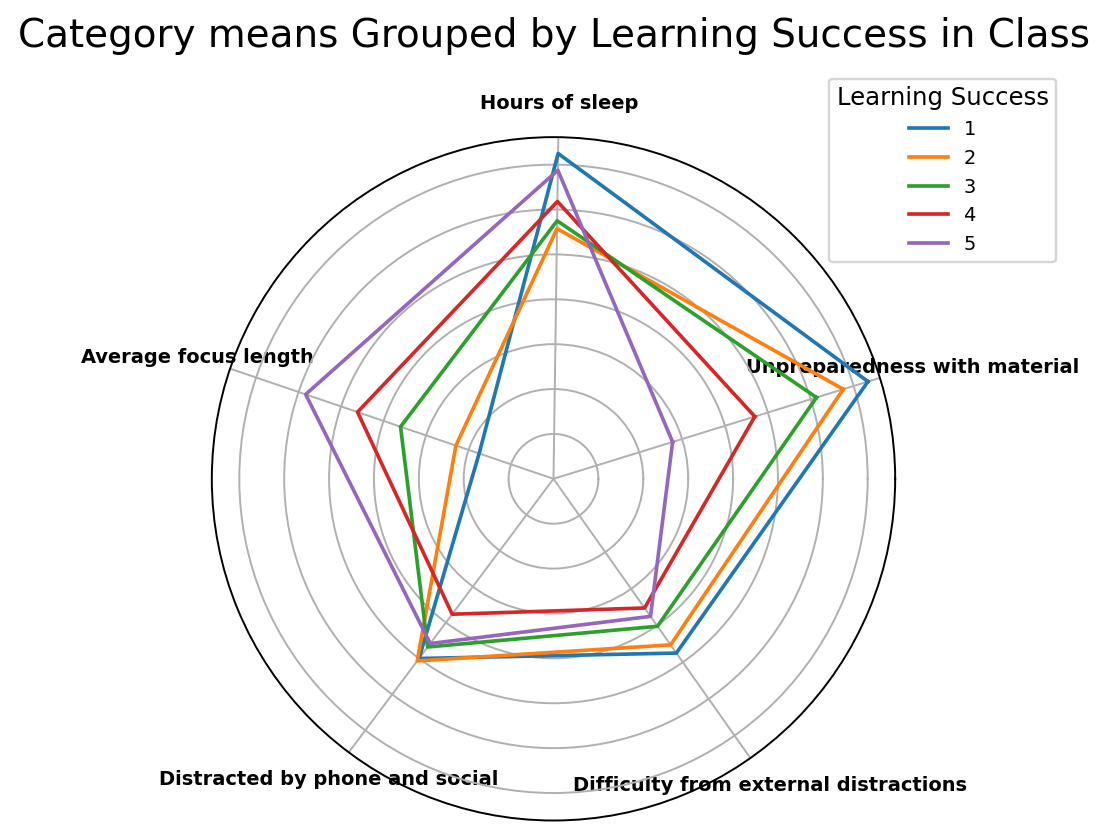

In [14]:
## DATA PREPARATION# tar_col is what we group by and df_filt are the categories we will visualize on the spider plot (copy to avoid changing original data)
tar_col = df['On a scale of 1-5, how well do you learn in class?'].copy(deep=True)
df_filt = df[['How often do you feel unprepared for a class due to not understanding the material?',
              'How many hours of sleep do you get on average during college?', 
              'What would you consider the average length of time you can stay focused in class?',
              'How often do you go on your phone or talk to your friends during class?',
              'How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?']].copy(deep=True)

# Rename columns to shorter versions so that the spider plot is readable
tar_col.rename('Learning success in class', inplace=True)
df_filt.rename(columns={
    'How often do you feel unprepared for a class due to not understanding the material?': 'Unpreparedness with material',
    'How many hours of sleep do you get on average during college?': 'Hours of sleep',
    'What would you consider the average length of time you can stay focused in class?': 'Average focus length',
    'How often do you go on your phone or talk to your friends during class?': 'Distracted by phone and social',
    'How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?': 'Difficulty from external distractions'
}, inplace=True)

# Create mappings for each of the ordinal categories
map_Q1= {'Never': 1, 'Rarely': 2, 'Often': 3, 'Very often': 4}
map_Q2= {'0 - 3 hours': 1.5, '4 - 5 hours': 4.5, '5 - 6 hours': 5.5, '6 - 7 hours': 6.5,
    '7 - 8 hours': 7.5, '8 - 9 hours': 8.5, '9 - 10 hours': 9.5}
map_Q3= {'0 - 20 mins': 10, '20 - 40 mins': 30, '40 - 60 mins': 50, '60 - 80 mins': 70, '80+ mins': 90}
map_Q4andQ5= {'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Often': 4, 'Always': 5}

# Apply mappings to the categorical columns# Apply mappings to the categorical columns
df_filt['Unpreparedness with material'] = df_filt['Unpreparedness with material'].map(map_Q1)
df_filt['Hours of sleep'] = df_filt['Hours of sleep'].map(map_Q2)
df_filt['Average focus length'] = df_filt['Average focus length'].map(map_Q3)
df_filt['Distracted by phone and social'] = df_filt['Distracted by phone and social'].map(map_Q4andQ5)
df_filt['Difficulty from external distractions'] = df_filt['Difficulty from external distractions'].map(map_Q4andQ5)

# Normalize each column with Min-Max normalization
df_filt_scaled = (df_filt - df_filt.min()) / (df_filt.max() - df_filt.min())

# Group by target column and find the mean for each category in a target
df_grouped = df_filt_scaled.groupby(tar_col).mean()


## SPIDER PLOT
# Get the number of categories (questions) and targets (Likert 1-5)
categories = df_grouped.columns.tolist()
num_categories = len(categories) # Defining length (5 categories)
targets = df_grouped.index.tolist()

# Create a figure for the spider plots
fig, ax = plt.subplots(figsize=(6, 6), dpi=175, subplot_kw=dict(polar=True))

# Set the angles of the categories and make the plot circular (adjusting the added number will change where the ticks are)
angles = np.linspace(0 + 0.3, 2 * np.pi + 0.3, num_categories, endpoint=False).tolist()
angles += angles[:1]

# Loop through each target value (1 through 5)
for target in targets:
    # Get the data for the target (first value appended to make circular)
    values = df_grouped.loc[target].tolist()
    values += values[:1]

    # Plot the spider plot for this target
    ax.plot(angles, values, linewidth=1.5, label=str(target), linestyle='solid')

# Set the category labels on the axes
ax.set_yticklabels([])  # Remove radial ticks (each inner circle is 0.1)
ax.set_xticks(angles[:-1])  # Set angles as 
ax.set_xticklabels(categories, ha='center', fontsize=8, fontweight='bold') # Set the labels as the categories

# Title, legend, figure location
plt.title('Category means Grouped by Learning Success in Class', size=16, y=1.11)
ax.legend(title="Learning Success", bbox_to_anchor=(1.25, 1.1), fontsize=8)

# Show the plot
plt.tight_layout()
plt.show()


&emsp;Upon evaluation of the spider chart, we can observe the relative importance of the different factors affecting learning success. The chart reveals that the most significant factors that lead to learning success are *Focus length* and *Material Preparedness*. Looking at the average focus length, it can be observed that the greater the self-reported learning success is, the longer the self-reported average focus length is. Additionally, when looking at how unprepared a student was before they went to class, we see that students with lower learning success (1 and 2) were much more unprepared than students with higher learning success (4 and 5). Each of these factors is in sequential order when looking at learning success and there is a decently sizeable gap between each group of learning successes and strength in category (negative relationship with unpreparedness with material which is the inverse of material preparedness).\
&emsp;When looking at the other categories, the categories *Difficulty from external distractions* and *Phone and Social Distractions* have a relatively minor impact on learning success according to the chart. While external distractions and social distractions play a role, they do not appear to be as crucial as other factors as the gap between each learning success is much smaller than in the other two major factors. While these factors are not perfectly sequential, the data between the nearby factors is close enough that it is arguable that these categories play a role.\
&emsp;The remaining factor, *Hours of sleep*, seems to be weakly correlated or uncorrelated with learning success. While hours of sleep can be argued to be correlated, learning success for students rated as 1 is significantly misplaced, being much higher than any of the other groups. While hours of sleep may influence learning success in a nonlinear method, the data from the spider chart does not support a clear or consistent relationship.
&emsp; For our project hypothesis, this implies a correlation between the classroom environment in terms of length and a minor impact from distractions in the classroom. However, there is also a major factor in material preparedness, which also influence our learning success in the classroom.

### Parallel coordinates plot
In this plot, I will group the data points in "How well do you learn in class?" (values 1 through 5) across the different categories of my data frame. I will display these groups on a parallel coordinates plot, which will be separated into subplots to avoid cluttering the data and making it unintelligible. This will show the different responses of people who chose each learning success level and will show in general which choices may be skewed due to the limited amount of people who chose that option.

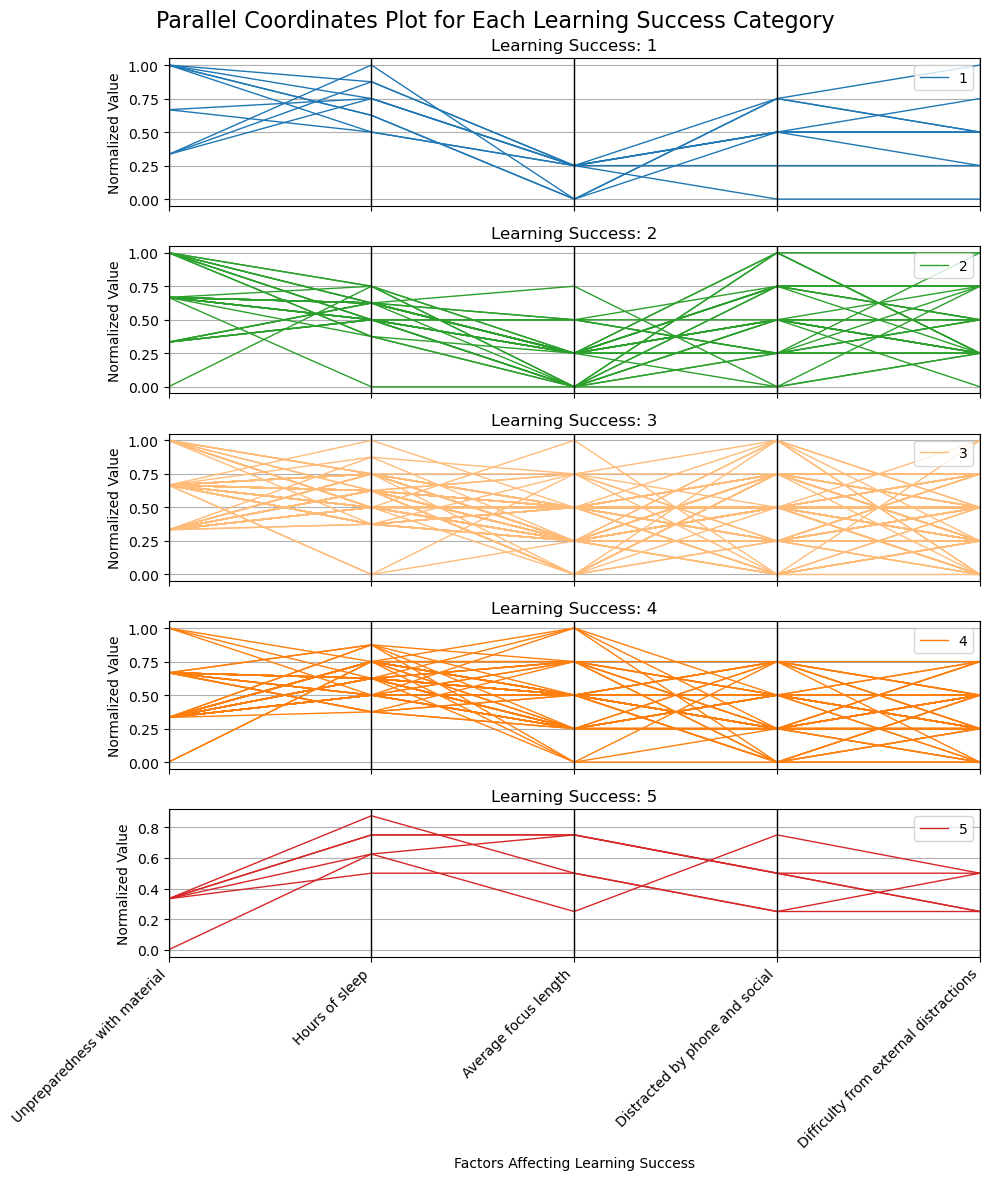

In [17]:
from pandas.plotting import parallel_coordinates

# Reuse the data that had been prepared in the previous plot
df_parallel = df_filt_scaled.copy()
df_parallel['learning success in class'] = tar_col

# Set up 5 subplots: 1 for each learning success rating
fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

# Iterate 5 times to get each subplot
for i in range(5):
    # Filter the DataFrame for the current target group (target group is from 1 - 5 hence i + 1)
    df_target = df_parallel[df_parallel['learning success in class'] == i + 1]
    
    # Create a parallel coordinates plot for this target group
    parallel_coordinates(
        # Data, target column, subplot location
        df_target, class_column='learning success in class', ax=axes[i], linewidth=1,
        # Color smoothly go from blue to red (i % 5 to choose index for each plot)
        color=['#1f77b4', '#2ca02c', '#ffbb78', '#ff7f0e', '#d62728'][i % 5]
    )
    
    # Set the title for each subplot
    axes[i].set_title(f"Learning Success: {i + 1}")
    axes[i].set_ylabel("Normalized Value")

# Set labels and rotate x ticks
fig.suptitle("Parallel Coordinates Plot for Each Learning Success Category", fontsize=16)
axes[4].set_xlabel("Factors Affecting Learning Success")
plt.xticks(rotation=45, ha='right')  # Rotate factor labels 

# Show the plot
plt.tight_layout()
plt.show()

&emsp;Looking at each of the parallel coordinates plot, we see that there are much less values for the learning success being equal to 1 and being equal to 5. This makes sense because there was much more people who chose the central values rather than the extreme values. For each category, we can see different patterns or no patterns that may be useful in determining whether there is insight to be gathered:
*  **Unpreparedness with material**: If we look at the first category, we notice that as the learning success gets greater, fewer lines are coming from the values that are closer to 1, and more lines coming from values closer to 0. This can be seen most greatly in categories 1 and 5, where there no values are coming from the bottom option in plot 1 and no values coming from the top 2 options in plot 5. This indicates a negative relationship between the learning success and the unpreparedness of a student.
*  **Hours of sleep**: Looking at hours of sleep category we see that many of the lines going into hours of sleep are very similar, with plots 1 and 5 being slightly higher than plots 2-4. This indicates that hours of sleep may not significantly affect our target, and if it does it may not follow a linear relationship.
*  **Average focus length**: For this question, we see that as the learning success gets higher, the points tend to be higher with the average focus length increasing. This indicates a positive relationship between learning success and material unpreparedness.
*  **Distracted by phone and social**: There doesn't seem to be a significant difference between each of the plots in terms of this category. There may be a weak or no correlation between being distracted by phone and social with learning success.
*  **Difficulty from external distractions**: Just like social distractions, it is hard to discern any significant relationship between this category and learning success.

### Stacked bar chart: Unpreparedness and Learning Success
The previous plots indicated that there was a relationship between learning success and material unpreparedness. To see this in more detail, we will be looking at the normalized values of the stacked bar chart responses to this question by group.

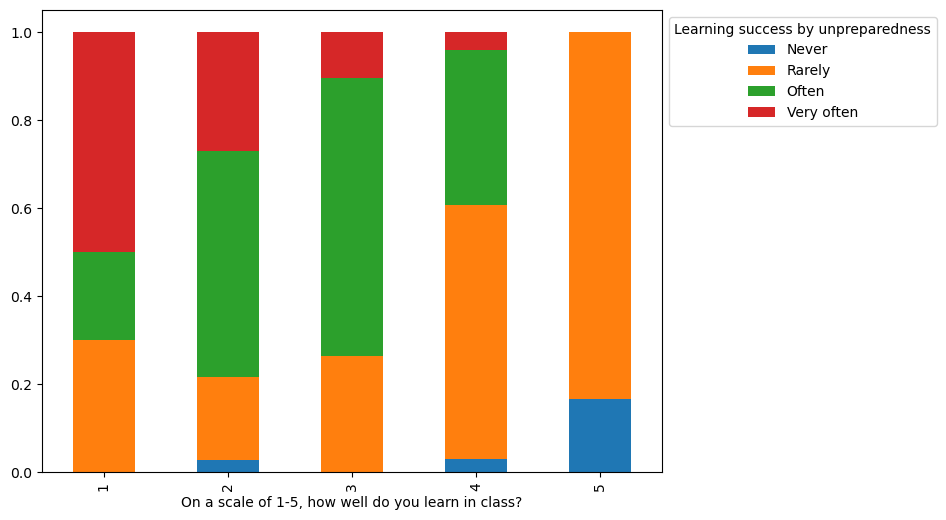

In [20]:
# Crosstab of relevant columns
crosstab = pd.crosstab(
    df['On a scale of 1-5, how well do you learn in class?'],
    df['How often do you feel unprepared for a class due to not understanding the material?'],
    colnames=["How unprepared from not understanding material"],
    normalize=0, margins=False
)

# Reorder the columns to 'Never', 'Rarely', 'Often', 'Very often'
column_order = ['Never', 'Rarely', 'Often', 'Very often']
crosstab = crosstab[column_order]

# Plot the stacked bar chart
ax = crosstab.plot.bar(stacked=True, figsize=(8, 6))

# Move legend to the outside
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title = "Learning success by unpreparedness")

# Plot
plt.show()

&emsp;As seen from stacked bar chart, as the student self reported a greater value for learning success, they more often than not answered that they rarely or never felt that they were unprepared for class. Inversely, as the scores get lowerm we see a greater proportion of responses saying that they often or very often felt they were unprepared for class due to not understanding the material. This reinforces the correlation between unpreparedness and learning rate that were suggested in both the spider and parallel coordinates chart.

### Stacked bar chart: Focus length and Learning Success

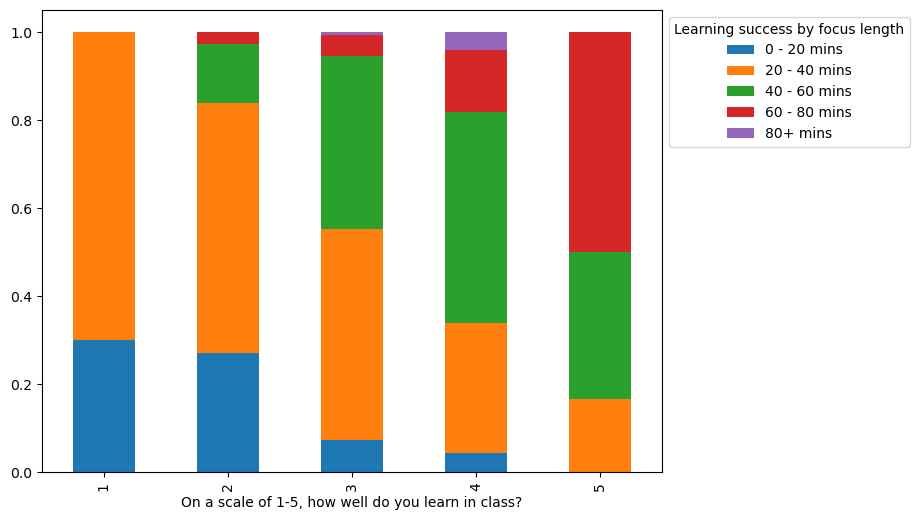

In [23]:
# Crosstab of relevant columns
crosstab = pd.crosstab(
    df['On a scale of 1-5, how well do you learn in class?'],
    df['What would you consider the average length of time you can stay focused in class?'],
    colnames=["Average Focus Time"],
    normalize = 0, margins=False
)

ax = crosstab.plot.bar(stacked=True, figsize=(8, 6))

# Move legend to the outside
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title = "Learning success by focus length")

# Plot
plt.show()

&emsp;The visualization computes the distribution of the students' ability to focus given how well they are able to learn. According to the stacked bar plot visualization, there seems to be an apparent relationship between how well students learn in class and how long they are able to focus. Those who claim that they can learn very well have greater focus times than those who struggle to learn.

### Heatmap: Social and External Distractions

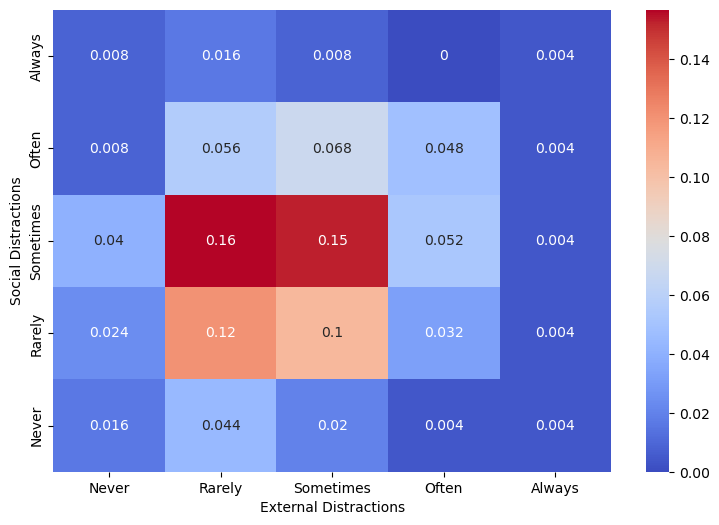

In [26]:
# Defined ordered_df and map that we will be using
ordered_df = df.copy(deep=True)
map_distractions = {'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Often': 4, 'Always': 5}

# Apply mapping on our selected columns
ordered_df['Social Distractions'] = ordered_df['How often do you go on your phone or talk to your friends during class?'].map(map_distractions)
ordered_df['External Distractions'] = ordered_df['How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?'].map(map_distractions)

# Raw counts
counts = pd.crosstab (
    ordered_df['Social Distractions'],
    ordered_df['External Distractions']
)

# Joint distribution
joint = counts / counts.sum().sum()

# Define order and size ~ Plot.
plt.figure(figsize=(9,6))
dist_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
fig = sns.heatmap(joint, annot=True, xticklabels=dist_order, yticklabels=dist_order, cmap='coolwarm')
fig.invert_yaxis()

# Plot
plt.show()

&emsp;When looking at the heatmap showing the distribution between phone time/time sent talking to friends and external distraction, our eyes are immediately drawn to a 2x2 square roughly in the center of the heatmap. This shows that students are generally going to have moderate amounts of social distractions and moderate amounts of external distractions.

### Bar chart: Factors on learning ability

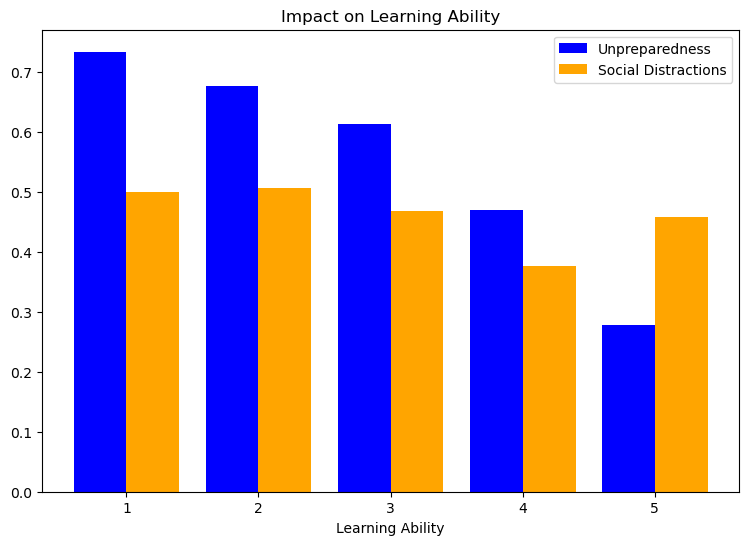

In [29]:
# Defined ordered_df maps that we will be using
map_unprepared= {'Never': 1, 'Rarely': 2, 'Often': 3, 'Very often': 4}
map_distractions = {'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Often': 4, 'Always': 5}

# Define index and values for our bar chart
idx = 'On a scale of 1-5, how well do you learn in class?'
val1 = 'How often do you feel unprepared for a class due to not understanding the material?'
val2 = 'How often do you go on your phone or talk to your friends during class?'

# Apply mappings on our ordered df copy
ordered_df = df.copy(deep=True)
ordered_df[val1] = ordered_df[val1].map(map_unprepared)
ordered_df[val2] = ordered_df[val2].map(map_distractions)

# Normalize values (Min-Max normalization)
scaled_df = ordered_df.copy(deep=True)
scaled_df[val1] = (ordered_df[val1] - ordered_df[val1].min()) / (ordered_df[val1].max() - ordered_df[val1].min())
scaled_df[val2] = (ordered_df[val2] - ordered_df[val2].min()) / (ordered_df[val2].max() - ordered_df[val2].min())

# Create pivot table means for val1 and val2 per learning success
table = pd.pivot_table(
    scaled_df,
    values=[val1,val2],
    index=idx,
    aggfunc='mean'
)

# Define width and plot bars
width = .4
plt.figure(figsize=(9,6))
plt.bar(table.index, table[val1], width, color='blue')
plt.bar(table.index + width, table[val2], width, color='orange')

# Add axis labels and title
xlab = "Learning Ability"
plt.xlabel(xlab)
plt.title("Impact on " + xlab)
plt.xticks(table.index + width / 2, [1,2,3,4,5])

# Show the plot
plt.legend(['Unpreparedness','Social Distractions'])
plt.show()

From the bar chart, we can see that learning ability and unpreparedness are inversely related / negatively correlated. We can also say that social distractions such as going on your phone or talking to your friends have little to no impact on learning ability. Therefore, we can deduce that social distractions must also have little to no effect on how well the students are prepared.

### Bar chart: Learning Effectiveness and Phone Use Frequency

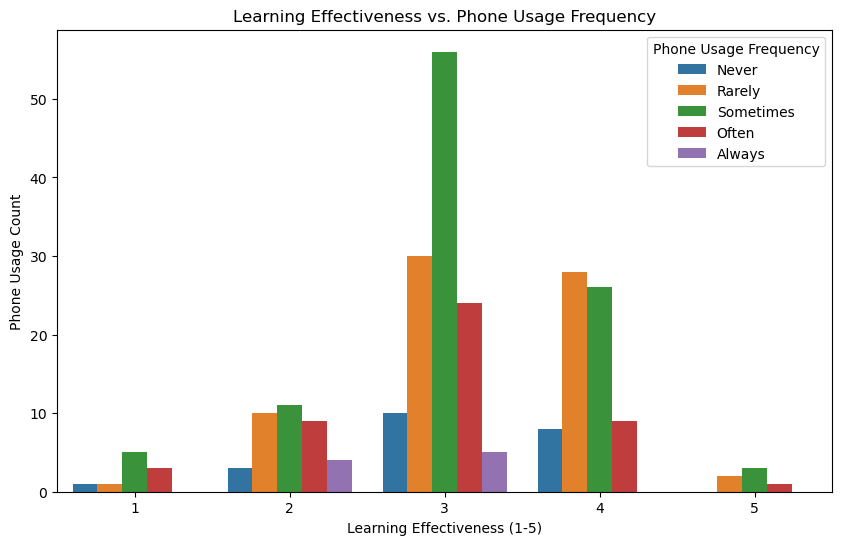

In [32]:
# Prepare fig size and plot Bar chart
plt.figure(figsize=(10, 6))
sns.countplot(
    x='On a scale of 1-5, how well do you learn in class?', 
    hue='How often do you go on your phone or talk to your friends during class?', 
    data=df_full,
    hue_order=['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
)

# Label editing for the chart
plt.title('Learning Effectiveness vs. Phone Usage Frequency')
plt.xlabel('Learning Effectiveness (1-5)')
plt.ylabel('Phone Usage Count')
plt.legend(title='Phone Usage Frequency')

# Display plot
plt.show()

&emsp;Students who indicate a higher level of learning effectiveness (ratings 4 and 5) have more students typically engage less with their phones during class; you can see that 4 and 5 don't have purple bars (Always use phones) and the height of the bars incidating the amount of people who are in the catagory of usage frequency. You can see that most students learning effectiveness ranges in the middle (rating 3) with "sometimes" for phone usage as the most common answer. This pattern suggests that moderate phone usage is common among students with average learning effectiveness, while students who feel they learn better tend to minimize distractions by using their phones less often.

### Boxplot: Focus time and External Distractions Frequency

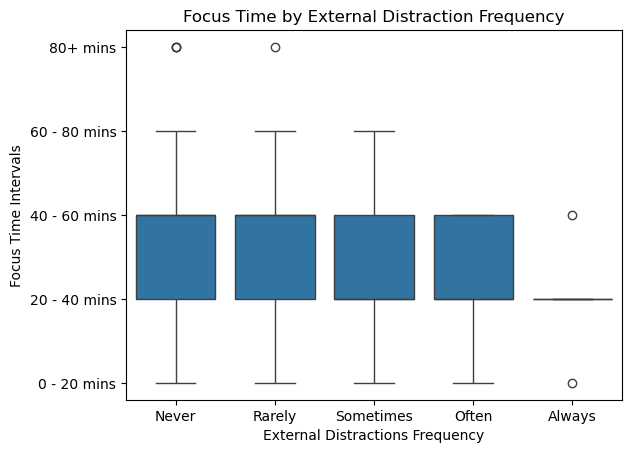

In [35]:
df_full['What would you consider the average length of time you can stay focused in class? '] = pd.Categorical(
    df_full['What would you consider the average length of time you can stay focused in class?'],
    categories=['0 - 20 mins', '20 - 40 mins', '40 - 60 mins', '60 - 80 mins', '80+ mins'],
    ordered=True
)

plt.figure
sns.boxplot(
    x='How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?', 
    y='What would you consider the average length of time you can stay focused in class? ', 
    data=df_full,
    order=['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
)
plt.gca().invert_yaxis()
plt.title('Focus Time by External Distraction Frequency')
plt.xlabel('External Distractions Frequency')
plt.ylabel('Focus Time Intervals')
plt.show()

&emsp;Our research indicates that students median focus time is around 20-40 mins across all levels of external distraction frequencies (Never- Always). In the section of "Never" and "Rarely" we can see that based on the outliers, a few students are able to focus by 80min or more in class when there are little to no external distractions. The majority of students generally maintain focus between 20 and 60 minutes. You can see that the more distracted someone is, the less time the student is able to maintain focus.

# Hypothesis

### Hypothesis 1
Students who rate their learning effectiveness lower are more likely to frequently go on their phones or talk to their friends.

In [39]:
# Prepare Columns for df_filt
df_filt = df[[
    'On a scale of 1-5, how well do you learn in class?',
    'What would you consider the average length of time you can stay focused in class?',
    'How often do you go on your phone or talk to your friends during class?',
    'How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?'
]].copy(deep=True)

# Rename columns to shorter versions
df_filt.rename(columns={
    'On a scale of 1-5, how well do you learn in class?': 'Learning_Effectiveness',
    'What would you consider the average length of time you can stay focused in class?': 'Focus_Time',
    'How often do you go on your phone or talk to your friends during class?': 'Phone_Talk_Frequency',
    'How often do you find it difficult to focus in class due to external distractions (e.g., noise, temperature, seating)?': 'External_Distractions'
}, inplace=True)

#rename columns in the dataframe for easier access in analysis
df_filt.columns = ['Learning_Effectiveness', 'Focus_Time', 'Phone_Talk_Frequency', 'External_Distractions']

#map text responses in the 'Focus_Time' column to numeric values for easier analysis
focus_time_map = {"0 - 20 mins": 1, "20 - 40 mins": 2, "40 - 60 mins": 3, "60 - 80 mins": 4, "80+ mins": 5}
#map text responses in 'Phone_Talk_Frequency' and 'External_Distractions' columns to numeric values as well
frequency_map = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Very Often": 5}

#apply the mappings to convert text responses to numeric categories in the dataframe
df_filt.loc[:, 'Focus_Time'] = df_filt['Focus_Time'].map(focus_time_map)
df_filt.loc[:, 'Phone_Talk_Frequency'] = df_filt['Phone_Talk_Frequency'].map(frequency_map)
df_filt.loc[:, 'External_Distractions'] = df_filt['External_Distractions'].map(frequency_map)

#drop any rows in the dataframe that have missing values in the selected columns
df_filt.dropna(inplace=True)

#step 1: categorize each variable into 'Low' and 'High' based on the median split
#categorize 'Learning_Effectiveness' into 'High' and 'Low' based on median
df_filt.loc[:, 'Learning_Effectiveness_Cat'] = np.where(df_filt['Learning_Effectiveness'] > df_filt['Learning_Effectiveness'].median(), 'High', 'Low')
#categorize 'Phone_Talk_Frequency' into 'High' and 'Low' based on median
df_filt.loc[:, 'Phone_Talk_Frequency_Cat'] = np.where(df_filt['Phone_Talk_Frequency'] > df_filt['Phone_Talk_Frequency'].median(), 'High', 'Low')
#categorize 'External_Distractions' into 'High' and 'Low' based on median
df_filt.loc[:, 'External_Distractions_Cat'] = np.where(df_filt['External_Distractions'] > df_filt['External_Distractions'].median(), 'High', 'Low')

#step 2: perform chi-square tests to determine associations

#test 1: chi-square test for association between 'Learning_Effectiveness' and 'Phone_Talk_Frequency'
#create a contingency table for chi-square test
contingency_table1 = pd.crosstab(df_filt['Learning_Effectiveness_Cat'], df_filt['Phone_Talk_Frequency_Cat'])
#if the contingency table is not empty, perform the chi-square test and print results; otherwise, note empty table
if not contingency_table1.empty:
    chi2_stat1, p_val1, dof1, ex1 = chi2_contingency(contingency_table1)
    print("Chi-square Test between Learning Effectiveness and Phone Use Frequency")
    print("Chi-square Statistic:", chi2_stat1, "P-value:", p_val1)
else:
    print("Contingency table for Learning Effectiveness and Phone Use Frequency is empty.")

#step 3: perform independent t-tests to compare means of learning effectiveness between groups

#check if sufficient data exists before running t-tests
#test 1: independent t-test to compare 'Learning_Effectiveness' between high and low 'Phone_Talk_Frequency' groups
#select data for high and low 'Phone_Talk_Frequency' groups
learning_effectiveness_high_phone = df_filt[df_filt['Phone_Talk_Frequency_Cat'] == 'High']['Learning_Effectiveness']
learning_effectiveness_low_phone = df_filt[df_filt['Phone_Talk_Frequency_Cat'] == 'Low']['Learning_Effectiveness']
#run t-test if both groups have more than one observation, then print results; otherwise, note insufficient data
if len(learning_effectiveness_high_phone) > 1 and len(learning_effectiveness_low_phone) > 1:
    t_stat1, p_val1 = ttest_ind(learning_effectiveness_high_phone, learning_effectiveness_low_phone, nan_policy='omit')
    print("\nIndependent t-test for Learning Effectiveness by Phone Use Frequency")
    print("t-statistic:", t_stat1, "P-value:", p_val1)
else:
    print("\nInsufficient data for t-test between Learning Effectiveness and Phone Use Frequency groups.")

Chi-square Test between Learning Effectiveness and Phone Use Frequency
Chi-square Statistic: 2.1848044806456337 P-value: 0.13937876261028917

Independent t-test for Learning Effectiveness by Phone Use Frequency
t-statistic: -1.6802198544453844 P-value: 0.09424899189936711


**Chi-square Test between Learning Effectiveness and Phone Use Frequency** \
&emsp;Our chi-square statistic is 2.18 and our p-value is 0.14, which is greater than the significance level of 0.05. Therefore, we cannot justify rejecting the null hypothesis. This result means that, according to our data, there is no statistically significant association between learning effectiveness and phone use frequency. In other words, students’ learning effectiveness does not appear to be significantly related to how often they use their phones during class.\**Independent t-test for Learning Effectiveness by Phone Use Frequency**\
&emsp;Our t-statistic is -1.68 and the p-value is 0.09, which is also greater than the significance level of 0.05. This result shows that there is no statistically significant difference in learning effectiveness between students who frequently use their phones and those who do not. This reinforces the chi-square test findings, suggesting that phone use frequency does not strongly impact learning effectiveness in this dataset.


### Hypothesis 2
Students who rate their learning effectiveness lower are more likely to report more difficulty focusing due to external distractions.

In [42]:
# Step 1 complete in previous analysis
#step 2: perform chi-square tests to determine associations

#test 2: chi-square test for association between 'Learning_Effectiveness' and 'External_Distractions'
#create a contingency table for chi-square test
contingency_table2 = pd.crosstab(df_filt['Learning_Effectiveness_Cat'], df_filt['External_Distractions_Cat'])
#if the contingency table is not empty, perform the chi-square test and print results; otherwise, note empty table
if not contingency_table2.empty:
    chi2_stat2, p_val2, dof2, ex2 = chi2_contingency(contingency_table2)
    print("\nChi-square Test between Learning Effectiveness and External Distractions")
    print("Chi-square Statistic:", chi2_stat2, "P-value:", p_val2)
else:
    print("Contingency table for Learning Effectiveness and External Distractions is empty.")

#step 3: perform independent t-tests to compare means of learning effectiveness between groups

#check if sufficient data exists before running t-tests
#test 2: independent t-test to compare 'Learning_Effectiveness' between high and low 'External_Distractions' groups
#select data for high and low 'External_Distractions' groups
learning_effectiveness_high_distraction = df_filt[df_filt['External_Distractions_Cat'] == 'High']['Learning_Effectiveness']
learning_effectiveness_low_distraction = df_filt[df_filt['External_Distractions_Cat'] == 'Low']['Learning_Effectiveness']
#run t-test if both groups have more than one observation, then print results; otherwise, note insufficient data
if len(learning_effectiveness_high_distraction) > 1 and len(learning_effectiveness_low_distraction) > 1:
    t_stat2, p_val2 = ttest_ind(learning_effectiveness_high_distraction, learning_effectiveness_low_distraction, nan_policy='omit')
    print("\nIndependent t-test for Learning Effectiveness by External Distractions")
    print("t-statistic:", t_stat2, "P-value:", p_val2)
else:
    print("\nInsufficient data for t-test between Learning Effectiveness and External Distractions groups.")


Chi-square Test between Learning Effectiveness and External Distractions
Chi-square Statistic: 3.2980135178572554 P-value: 0.06936371968402619

Independent t-test for Learning Effectiveness by External Distractions
t-statistic: -1.9890698227034374 P-value: 0.04785810333011402


**Chi-square Test between Learning Effectiveness and External Distractions**\
&emsp;Our chi-square statistic is 3.30 and our p-value is 0.07, which is slightly above the significance level of 0.05. While this does not meet the conventional threshold for significance, the p-value is close, suggesting a potential trend that might be worth further investigation at a lower significance level. However, for now, we cannot reject the null hypothesis, meaning that our data does not provide strong statistical support for a significant relationship between learning effectiveness and external distractions. However the p value is close to .05 enough so that we have to warrant in an actual case of data analysis another look for a statistical correlation.\
**Independent t-test for Learning Effectiveness by External Distractions**\
&emsp;Our t-statistic is -1.99 and the p-value is 0.048, which is below the significance level of 0.05. This allows us to reject the null hypothesis, indicating a statistically significant difference in learning effectiveness between students who report high and low levels of external distractions. This finding suggests that students who experience fewer external distractions tend to have higher learning effectiveness, which supports our hypothesis.



### Hypothesis 3
Students who sleep less on average during college are less likely to learn well in a class. I will be performing the correlation analysis test for this hypothesis and try to find if the hypothesis is true. Additionally, I will be performing t statistic test.

In [45]:
df = pd.read_csv('CS105 F24 Mini-Project Survey (Responses) - Form Responses 1.csv')

df_filt = df[['How many hours of sleep do you get on average during college?',
       'On a scale of 1-5, how well do you learn in class?']].copy(deep=True)

# Rename columns to shorter versions
df_filt.rename(columns={
    'How many hours of sleep do you get on average during college?': 'Sleep_Average',
    'On a scale of 1-5, how well do you learn in class?': 'Learning_Effectiveness',
}, inplace=True)

#rename columns in the dataframe for easier access in analysis
df_filt.columns = ['Sleep_Average', 'Learning_Effectiveness']

# Convert sleep categories to numerical values
sleep_mapping = {
    '0 - 3 hours': 1,
    '4 - 5 hours': 2,
    '5 - 6 hours': 3,
    '6 - 7 hours': 4,
    '7 - 8 hours': 5,
    '8 - 9 hours': 6,
    '9 - 10 hours': 7
}

# Apply the mapping to create a numerical column for sleep
df_filt['Sleep_Average'] = df_filt['Sleep_Average'].map(sleep_mapping)

# Load the dataset with frame
df_full = df_filt

# Calculate correlations
x = df_full['Sleep_Average']

y = pd.Series([1, 2, 3, 4, 5])

x.corr(y) 
y.corr(x)

# Find the pearson correlations matrix
corr = df_full.corr(method = 'pearson')
print(corr)

# correlations between sleep avergae and learning effectiveness columns
c = np.corrcoef(df_full['Sleep_Average'],df_full['Learning_Effectiveness'])
print('\nCorrelation between students sleep time on average and how well they learn in class is 0.0452.\n')
print("This shows that there is little correlation between the two variables.")

# Perform the two sample t-test with equal variances
stats.ttest_ind(a=df_full['Sleep_Average'], b=df_full['Learning_Effectiveness'], equal_var=True)

                        Sleep_Average  Learning_Effectiveness
Sleep_Average                1.000000                0.045232
Learning_Effectiveness       0.045232                1.000000

Correlation between students sleep time on average and how well they learn in class is 0.0452.

This shows that there is little correlation between the two variables.


TtestResult(statistic=7.764535920922357, pvalue=4.728704701417189e-14, df=496.0)

Since the correlation coefficient (R value) was found to be 0.0452 between the average number of hours of sleep a student gets during their time in college and how well they learn in class, there is little correlation between them so the hypothesis is not true.\
The t-stat value of 7.76 tells us that it is statistically significant and since the p-value was less than 0.0001, we can say it is highly statistically significant.

# Conclusion

&emsp;Our first hypothesis states that "students who rate their learning effectiveness lower are more likely to frequently go on their phones or talk to friends during class and report more difficulty focusing due to external distractions." The test for this hypthosis yielded the conclusion that we should accept the null hypothesis which means that social and external distractions do not impact students' learning rates, which is in agreement with the visualization of the bar chart and spider chart. This differs from our hypothesis because we believed that it would have an affect them.\
&emsp;The second hypothesis we made stated that "students who report longer focus times in class also report fewer distractions, such as phone use and external factors," however like our first hypthosis, our tests accept the null hypothesis so there is no such correlation.\
&emsp;The third hypothesis performs a pearson correlation test and a t-test, which led to inconclusive results as the pearson correlation concluded no relation and the t test concluded there was significance.\
&emsp;When analyzing both the tests and visualizations together, we see that one of our bar chart visualizations showed that there is a positive correlation between ability to learn and focus times. Our other visualization showed that there was no correlation between distractions and learning ability. Therefore this also means that there is no correlation between distractions and focus times. This claim is further reinforced by the second hypothesis's test.\
&emsp;Now relating this back to our original question about whether or not the classroom environment affects students' ability to learn; We can say that **NO** the classroom environment does not affect students' ability to learn. However, some other interesting findings that we found was that students' feeling of unpreparedness has a negative correlation with learning, so we can assume that the classroom environment also does not affect how prepared students feel. Moreover, another research idea if we were to continue this would be seeing if the mentality of students plays a factor in their ability to understand class material.

## Work Split
* What data do you have? - Kyle Russell
* What would you like to know? - Jimmy Wu
* Plots 1-3 - Kyle Russell
* Plots 4-6 - Jason Nguyen
* Plots 7-8 - Jimmy Wu
* Hypothesis 1-2 (chi-squared and t-test) - Will Kirkpatrick
* Hypothesis 3 - Ahad Hassan
* Conclusion - Jason Nguyen